In [6]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

In [7]:
from sklearn.datasets import fetch_california_housing

df = fetch_california_housing(as_frame=True)

x = df.data
y = df.target

x[:5]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Подберем гиперпараметры дерева по кросс-валидации

In [8]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

params = {'max_depth': np.arange(2,10),
          'min_samples_split': np.arange(2,10,2),
          'min_samples_leaf': np.arange(1,10,2)
          }

gs = GridSearchCV(DecisionTreeRegressor(), params, cv=3, scoring='r2', verbose=2)

gs.fit(x,y)

Fitting 3 folds for each of 160 candidates, totalling 480 fits
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=6; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=6; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=6; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=8; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=8; total time=   0.0s
[CV] END max_depth=2, min_samples_l

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([2, 3, ..., 6, 7, 8, 9]), 'min_samples_leaf': array([1, 3, 5, 7, 9]), 'min_samples_split': array([2, 4, 6, 8])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [9]:
gs.best_estimator_, gs.best_score_

(DecisionTreeRegressor(max_depth=np.int64(5), min_samples_leaf=np.int64(9),
                       min_samples_split=np.int64(2)),
 np.float64(0.5390892243233139))

Используем прунинг для уменьшения количества вершин в дереве и, следовательно, для снижения переобучения.

Прунинг при обучении дерева использует регуляризованный функционал  

B sklearn есть Cost-Complexity pruning, который возвращает список возможных порогов  α  при построении дерева
(т.к. данных конечное число, то не нужно рассматривать бесконечное число значений).

In [11]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

tree = DecisionTreeRegressor()

path = tree.cost_complexity_pruning_path(xtrain, ytrain)
alphas = path['ccp_alphas']
alphas

array([0.00000000e+00, 4.30319002e-20, 5.73758669e-20, ...,
       7.95140486e-02, 1.01733053e-01, 4.20802794e-01], shape=(13918,))

In [12]:
len(alphas)

13918

Чем больше  α , тем сильнее регуляризация, и тем меньше дерево переобучается.

Посмотрим на зависимость качества предсказания дерева на тренировочных и тестовых данных в зависимости от α .

Для отображения прогресса выполнения ячейки используем библиотеку tqdm

In [13]:
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

cv_score = []

for i in tqdm(alphas[::100]):
    tree = DecisionTreeRegressor(ccp_alpha=i)
    cv = cross_val_score(tree, x, y, cv=3, scoring='r2').mean()
    cv_score.append(cv)

100%|██████████| 140/140 [05:06<00:00,  2.19s/it]


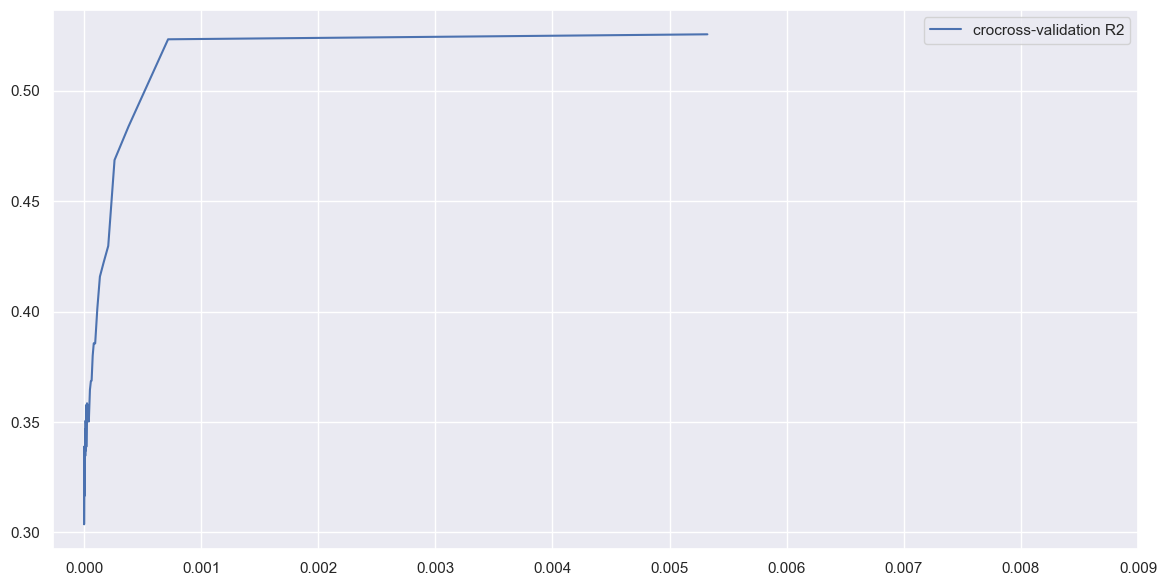

In [14]:
sns.set_theme()
plt.figure(figsize=(14,7))
sns.lineplot(y=cv_score, x= alphas[::100], label='crocross-validation R2')
plt.xticks(ticks=np.arange(0.00,0.01,0.001))
plt.show()

Мы видим, что аккуратный подбор гиперпараметра  α  при прунинге позволяет улучшить качество модели.

Также можно комбинировать прунинг и подбор других гиперпараметров - это долгая кропотливая работа.